In [6]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

load_dotenv(override=True)

url = URL.create(
    "postgresql+psycopg2",
    username=os.environ.get("DB_USER", "postgres"),
    password=os.environ["DB_PASSWORD"],
    host=os.environ.get("DB_HOST", "localhost"),
    port=os.environ.get("DB_PORT", "5432"),
    database=os.environ.get("DB_NAME", "finguard_db"),
)
engine = create_engine(url)

# Load our engineered feature set (not the raw transactions table)
df = pd.read_sql("SELECT * FROM transactions_features", engine)
print(df.shape)

(284807, 36)


In [7]:
# Data is already in chronological order (we sorted by Time in Week 3)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTrain fraud rate: {train_df['Class'].mean()*100:.4f}%")
print(f"Test fraud rate: {test_df['Class'].mean()*100:.4f}%")

Train shape: (227845, 36)
Test shape: (56962, 36)

Train fraud rate: 0.1830%
Test fraud rate: 0.1317%


In [8]:
# Drop Class (target) and Amount (raw, unscaled - we use Amount_Log instead) from features
feature_cols = [c for c in df.columns if c not in ['Class', 'Amount']]

X_train = train_df[feature_cols]
y_train = train_df['Class']

X_test = test_df[feature_cols]
y_test = test_df['Class']

print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Features used (34): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour', 'Is_High_Risk_Hour', 'Amount_Log', 'Amount_Zscore', 'Is_Round_Amount', 'Txn_Count_Last_Hour']
X_train: (227845, 34), y_train: (227845,)
X_test: (56962, 34), y_test: (56962,)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data, then apply to both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Scaling complete.
X_train_scaled shape: (227845, 34)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    precision_recall_curve, auc, roc_auc_score
)

# class_weight='balanced' handles imbalance by penalizing misclassifying the minority (fraud) class more
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression — Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# PR-AUC (the metric that actually matters here, not accuracy)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print(f"\nPR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      0.95      0.98     56887
       Fraud       0.03      0.93      0.05        75

    accuracy                           0.95     56962
   macro avg       0.51      0.94      0.51     56962
weighted avg       1.00      0.95      0.97     56962

=== Confusion Matrix ===
[[54237  2650]
 [    5    70]]

PR-AUC: 0.7686
ROC-AUC: 0.9879


In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
y_pred_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

print("=== Decision Tree — Classification Report ===")
print(classification_report(y_test, y_pred_dt, target_names=['Legit', 'Fraud']))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_dt))

precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_proba_dt)
pr_auc_dt = auc(recall_dt, precision_dt)
print(f"\nPR-AUC: {pr_auc_dt:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56887
       Fraud       0.06      0.79      0.11        75

    accuracy                           0.98     56962
   macro avg       0.53      0.88      0.55     56962
weighted avg       1.00      0.98      0.99     56962

=== Confusion Matrix ===
[[55918   969]
 [   16    59]]

PR-AUC: 0.2251
ROC-AUC: 0.8968


In [12]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42, sampling_strategy=0.1)  # brings fraud to 10% of majority class, not full 50/50 (avoids overcorrecting)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

Before SMOTE: {0: 227428, 1: 417}
After SMOTE: {0: 227428, 1: 22742}


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_scaled)
y_pred_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest — Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_rf))

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
print(f"\nPR-AUC: {pr_auc_rf:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.60      0.79      0.68        75

    accuracy                           1.00     56962
   macro avg       0.80      0.89      0.84     56962
weighted avg       1.00      1.00      1.00     56962

=== Confusion Matrix ===
[[56847    40]
 [   16    59]]

PR-AUC: 0.7963
ROC-AUC: 0.9772


In [14]:
from xgboost import XGBClassifier

# scale_pos_weight approximates class balance without needing full SMOTE reliance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test_scaled)
y_pred_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost — Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_xgb))

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)
print(f"\nPR-AUC: {pr_auc_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.30      0.77      0.43        75

    accuracy                           1.00     56962
   macro avg       0.65      0.89      0.72     56962
weighted avg       1.00      1.00      1.00     56962

=== Confusion Matrix ===
[[56752   135]
 [   17    58]]

PR-AUC: 0.7661
ROC-AUC: 0.9573


In [15]:
xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
# Train on ORIGINAL scaled data, not SMOTE-resampled — let scale_pos_weight alone handle imbalance
xgb_v2.fit(X_train_scaled, y_train)

y_pred_xgb2 = xgb_v2.predict(X_test_scaled)
y_pred_proba_xgb2 = xgb_v2.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost (no SMOTE, scale_pos_weight only) ===")
print(classification_report(y_test, y_pred_xgb2, target_names=['Legit', 'Fraud']))
print(confusion_matrix(y_test, y_pred_xgb2))

precision_xgb2, recall_xgb2, _ = precision_recall_curve(y_test, y_pred_proba_xgb2)
pr_auc_xgb2 = auc(recall_xgb2, precision_xgb2)
print(f"\nPR-AUC: {pr_auc_xgb2:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb2):.4f}")

=== XGBoost (no SMOTE, scale_pos_weight only) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.87      0.73      0.80        75

    accuracy                           1.00     56962
   macro avg       0.94      0.87      0.90     56962
weighted avg       1.00      1.00      1.00     56962

[[56879     8]
 [   20    55]]

PR-AUC: 0.7894
ROC-AUC: 0.9839


In [16]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train_scaled, y_train)

y_pred_lgbm = lgbm.predict(X_test_scaled)
y_pred_proba_lgbm = lgbm.predict_proba(X_test_scaled)[:, 1]

print("=== LightGBM — Classification Report ===")
print(classification_report(y_test, y_pred_lgbm, target_names=['Legit', 'Fraud']))
print(confusion_matrix(y_test, y_pred_lgbm))

precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_pred_proba_lgbm)
pr_auc_lgbm = auc(recall_lgbm, precision_lgbm)
print(f"\nPR-AUC: {pr_auc_lgbm:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lgbm):.4f}")

=== LightGBM — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56887
       Fraud       0.04      0.77      0.08        75

    accuracy                           0.98     56962
   macro avg       0.52      0.87      0.53     56962
weighted avg       1.00      0.98      0.99     56962

[[55552  1335]
 [   17    58]]

PR-AUC: 0.4078
ROC-AUC: 0.8590


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=10,               # tries 10 random combinations (keeps runtime reasonable)
    scoring='average_precision',  # this is PR-AUC — the metric that matters here
    cv=3,                    # 3-fold cross-validation
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_smote, y_train_smote)

print("Best params:", rf_search.best_params_)
print("Best CV PR-AUC:", rf_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
best_rf = rf_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test_scaled)
y_pred_proba_best_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print("=== Tuned Random Forest — Test Set Results ===")
print(classification_report(y_test, y_pred_best_rf, target_names=['Legit', 'Fraud']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

precision_best_rf, recall_best_rf, _ = precision_recall_curve(y_test, y_pred_proba_best_rf)
pr_auc_best_rf = auc(recall_best_rf, precision_best_rf)
print(f"\nTest PR-AUC: {pr_auc_best_rf:.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best_rf):.4f}")

=== Tuned Random Forest — Test Set Results ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.71      0.79      0.75        75

    accuracy                           1.00     56962
   macro avg       0.86      0.89      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56863    24]
 [   16    59]]

Test PR-AUC: 0.8021
Test ROC-AUC: 0.9831


In [ ]:
import joblib

# Save the final model for reuse in later notebooks (SHAP, Streamlit app)
joblib.dump(best_rf, '../models/final_rf_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.


In [ ]:
import sys
!{sys.executable} -m pip install shap

'c:\Users\souja\OneDrive\Desktop\Project' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import shap
import numpy as np

# Sample 2000 rows for SHAP analysis (representative, much faster than full 57K test set)
np.random.seed(42)
sample_idx = np.random.choice(X_test_scaled.shape[0], size=2000, replace=False)
X_test_sample = X_test_scaled[sample_idx]

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated on 2000-row sample.")
print(f"Shape: {np.array(shap_values).shape}")

SHAP values calculated on 2000-row sample.
Shape: (2000, 34, 2)


C:\Users\souja\AppData\Local\Temp\ipykernel_18396\3966916444.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_fraud, X_test_sample, feature_names=feature_cols, plot_type="bar", show=False)


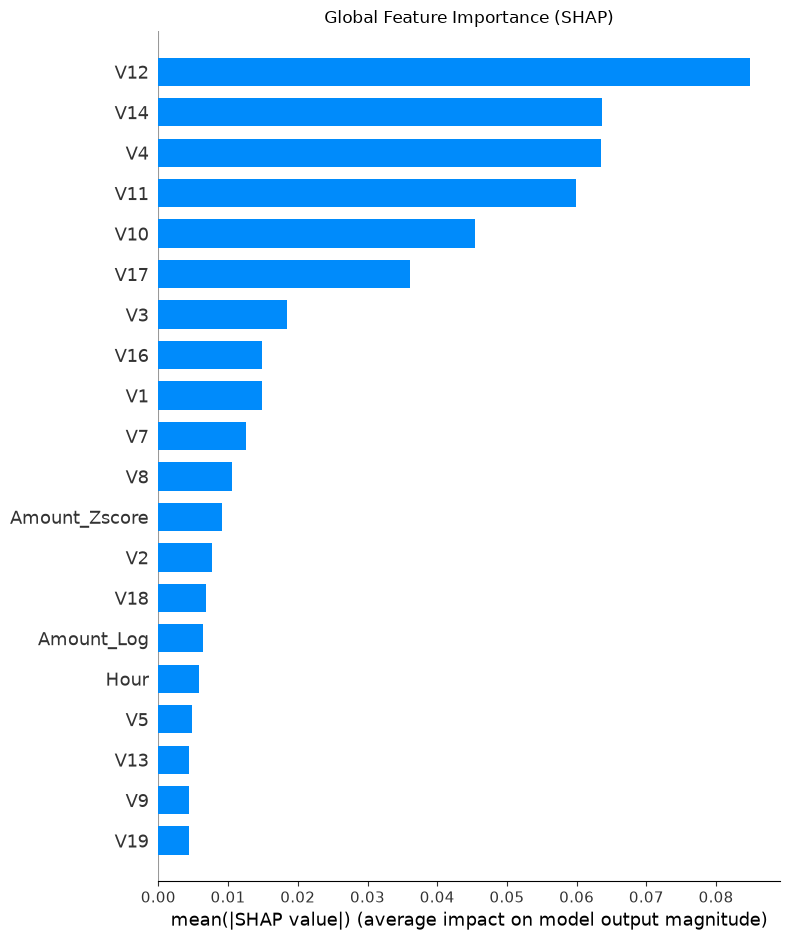

In [ ]:
import matplotlib.pyplot as plt

# Use shap_values for the "Fraud" class (index 1)
shap_values_fraud = shap_values[:, :, 1] if np.array(shap_values).ndim == 3 else shap_values[1]

# Summary plot: shows feature importance ranked by impact
shap.summary_plot(shap_values_fraud, X_test_sample, feature_names=feature_cols, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../reports/shap_feature_importance.png", dpi=150)
plt.show()

Number of fraud cases in sample: 2


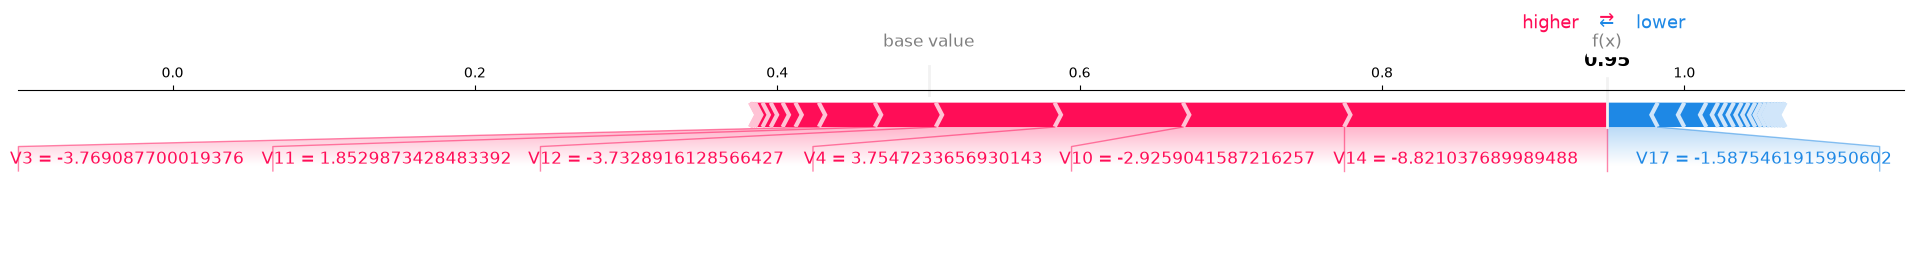

In [ ]:
# Pick one actual fraud case from our sample to explain individually
fraud_indices_in_sample = np.where(y_test.iloc[sample_idx].values == 1)[0]
print(f"Number of fraud cases in sample: {len(fraud_indices_in_sample)}")

if len(fraud_indices_in_sample) > 0:
    idx_to_explain = fraud_indices_in_sample[0]
    
    shap.force_plot(
        explainer.expected_value[1], 
        shap_values_fraud[idx_to_explain], 
        X_test_sample[idx_to_explain],
        feature_names=feature_cols,
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    plt.savefig("../reports/shap_single_fraud_explanation.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No fraud cases in this sample — try a larger sample size")